In [ ]:
# 既にインストールされていれば不要
!pip install quri-parts
!pip install "quri-parts[qulacs]"

In [2]:
import numpy as np

N = 8 # 質点の数
k_list = np.arange(1, N+1)[::-1] # ばね定数
F = 2. # 右端の質点にかかる力
print("ばね定数:", k_list)

# 係数行列
A_mat = np.zeros((N, N), dtype=float)
for i in range(N):
    # 左のばねからの寄与
    A_mat[i, i] += k_list[i]
    if i > 0: A_mat[i, i-1] += - k_list[i]
    # 右のばねからの寄与
    if i < N-1:
        A_mat[i, i+1] += - k_list[i+1]
        A_mat[i, i] += k_list[i+1]

print("係数行列A:\n", A_mat)

b_vec = np.zeros(N, dtype=float)
b_vec[N-1] = F # N-1 番目の質点に力がかかる

# 厳密解を求めて，ばねの伸びを計算
x_exact = np.linalg.solve(A_mat, b_vec)
print("ばねの伸び:", np.diff(x_exact, prepend=0))

ばね定数: [8 7 6 5 4 3 2 1]
係数行列A:
 [[15. -7.  0.  0.  0.  0.  0.  0.]
 [-7. 13. -6.  0.  0.  0.  0.  0.]
 [ 0. -6. 11. -5.  0.  0.  0.  0.]
 [ 0.  0. -5.  9. -4.  0.  0.  0.]
 [ 0.  0.  0. -4.  7. -3.  0.  0.]
 [ 0.  0.  0.  0. -3.  5. -2.  0.]
 [ 0.  0.  0.  0.  0. -2.  3. -1.]
 [ 0.  0.  0.  0.  0.  0. -1.  1.]]
ばねの伸び: [0.25       0.28571429 0.33333333 0.4        0.5        0.66666667
 1.         2.        ]


In [3]:
# 行列Aを対角化して固有値が[0, 2pi]に収まるようにスケールする
eigs_A, vecs_A = np.linalg.eigh(A_mat)
print("Aの固有値:", eigs_A)
condition_number = np.max(np.abs(eigs_A)) / np.min(np.abs(eigs_A))
print("Aの条件数:", condition_number)
scale_factor_A = 1.9 * np.pi / np.max(np.abs(eigs_A)) # 最大固有値を1.9piにする
A_mat_scaled = A_mat * scale_factor_A # スケールされた行列
print("スケールされたAの固有値", np.linalg.eigh(A_mat_scaled)[0])
# ベクトルbを規格化
scale_factor_b = 1. / np.sqrt( sum(np.abs(b_vec)**2) )
b_vec_scaled = b_vec * scale_factor_b

Aの固有値: [ 0.17027963  0.90370178  2.25108663  4.26670017  7.0459054  10.75851601
 15.74067864 22.86313174]
Aの条件数: 134.26815308083303
スケールされたAの固有値 [0.04445601 0.23593528 0.58770578 1.11393508 1.83952021 2.80879553
 4.10952103 5.96902604]


In [4]:
from quri_parts.circuit import QuantumCircuit
from quri_parts.circuit import inverse_circuit

def create_qft_circuit(n_qubits: int, start_bit: int, end_bit: int, inverse=False
                       ) -> QuantumCircuit:
    # 量子ビットのインデックスは|j_{n-1} j_{n-2}...j_0>の順番であることに注意
    n = end_bit - start_bit + 1
    circuit = QuantumCircuit(n_qubits)

    for i in reversed(range(start_bit, end_bit + 1)): # i は end_bit から start_bit まで
        circuit.add_H_gate(i)
        for j in range(start_bit, i): # j は start_bit から i-1 まで
            # 制御位相ゲートを4*4行列で定義
            angle = 2 * np.pi / (2 ** (i - j + 1))
            control_phase_mat = np.diag([1,1,1, np.exp(1j * angle)])
            circuit.add_UnitaryMatrix_gate([j, i], control_phase_mat)

    # 量子ビットの順序を反転
    for k in range(n // 2):
        circuit.add_SWAP_gate(start_bit + k, end_bit - k)

    if inverse:
        return inverse_circuit(circuit).freeze()

    return circuit.freeze()


def create_qpe_circuit(n_qubits, unitary_mat, n_reg_qubits: int,) -> QuantumCircuit:
    """ HHLアルゴリズムの量子位相推定アルゴリズム部分を実装
    - 全体の量子ビット数は n_qubits
    - index = 0 から n_system_qubits-1 はシステムレジスタ
    - n_system_qubits から n_system_qubits + n_reg_qubits-1 は
      量子位相推定アルゴリズム用のクロックレジスタ
    """
    mat_size = unitary_mat.shape[0]
    n_system_qubits = int(np.log2(mat_size))
    circuit = QuantumCircuit(n_qubits)

    # アダマールゲートをクロックレジスタに適用
    for i in range(n_system_qubits, n_system_qubits+n_reg_qubits):
        circuit.add_H_gate(i)

    # 制御ユニタリゲートを適用
    for i in range(n_system_qubits, n_system_qubits+n_reg_qubits):
        gate_mat = np.linalg.matrix_power(unitary_mat, 2**(i - n_system_qubits))
        control_gate_mat = np.zeros((2*mat_size, 2*mat_size), dtype=complex)
        control_gate_mat[:mat_size, :mat_size] = np.eye(mat_size)
        control_gate_mat[mat_size:, :][:, mat_size:] = gate_mat
        circuit.add_UnitaryMatrix_gate(list(range(n_system_qubits)) + [i], control_gate_mat)

    # 逆量子フーリエ変換を適用
    qft_circuit = create_qft_circuit(
        n_qubits, n_system_qubits, n_system_qubits+n_reg_qubits-1, inverse=True
    )
    circuit.extend(qft_circuit)

    return circuit

※書籍版からの変更点：文法エラーを防ぐため、`create_hhl_circuit`の引数の括弧の位置を調整しました。

In [5]:
def create_conditional_rotation_circuit(
    n_qubits: int, n_system_qubits: int, n_reg_qubits: int, c: float
    ) -> QuantumCircuit:
    """
    |i> をクロックレジスタ，lam を対応する二進小数として以下の制御回転ゲートを実装
    |0>|i> -> sqrt(1 - c^2/lam^2) |0>|i> + c/lam |1>|i>
    |1>|i> -> - c/lam |0>|i> + sqrt(1 - c^2/lam^2) |1>|i>
    """
    condrot_mat = np.zeros( (2**(n_reg_qubits+1), (2**(n_reg_qubits+1))), dtype=float)
    for i in range(2**n_reg_qubits):
        lam = 2 * np.pi * (float(i) / (2 ** n_reg_qubits) )
        index_0 = i # |0>|i>に対応する整数
        index_1 = i + 2**n_reg_qubits # |1>|i>に対応する整数
        if lam >= c:
            condrot_mat[index_0, index_0] = np.sqrt( 1 - c**2/lam**2 )
            condrot_mat[index_1, index_0] = c / lam
            condrot_mat[index_0, index_1] = - c / lam
            condrot_mat[index_1, index_1] = np.sqrt( 1 - c**2/lam**2 )
        else: # 固有値がc より小さい場合は，単に回転しない
            condrot_mat[index_0, index_0] = 1.
            condrot_mat[index_1, index_1] = 1.
    circuit = QuantumCircuit(n_qubits)
    circuit.add_UnitaryMatrix_gate(
    list(range(n_system_qubits, n_system_qubits+n_reg_qubits)) + [n_qubits-1],
    condrot_mat
    )
    return circuit

def create_hhl_circuit(
    n_system_qubits: int,
    n_reg_qubits: int,
    hermitian_matrix,
    c: float
    ) -> QuantumCircuit:
    # 対角化を使ってU = e^{iA}に対応するユニタリ行列を作成
    D, P = np.linalg.eigh(hermitian_matrix)
    U_mat = P @ np.diag(np.exp( 1.j * D )) @ P.T.conj()

    n_qubits = n_system_qubits + n_reg_qubits + 1

    qpe_circuit = create_qpe_circuit(n_qubits, U_mat, n_reg_qubits)
    condrot_circuit = create_conditional_rotation_circuit(
        n_qubits, n_system_qubits, n_reg_qubits, c
    )

    circuit = QuantumCircuit(n_qubits)
    circuit.extend(qpe_circuit)
    circuit.extend(condrot_circuit)
    circuit.extend(inverse_circuit(qpe_circuit))

    return circuit

In [6]:
from quri_parts.core.state import quantum_state
from quri_parts.qulacs.simulator import evaluate_state_to_vector

# 量子ビット数を定義
n_system_qubits = np.ceil(np.log2(N)).astype(int) # 質点の数に対応する量子ビット数
n_reg_qubits = 8 # クロックレジスタの量子ビット数
n_qubits = n_system_qubits + n_reg_qubits + 1 # +1 は補助量子ビットの分

# 状態|b>を用意
init_vec = np.zeros(2**n_qubits, dtype=complex)
init_vec[:2**n_system_qubits] = b_vec_scaled.copy() # 補助ビット部分は0...0

# 制御回転のための定数c は位相推定の最小固有値の定数倍とする
c_factor = 0.9 * (2 * np.pi / 2**n_reg_qubits)
# 回路の作成
hhl_circuit = create_hhl_circuit(n_system_qubits, n_reg_qubits, A_mat_scaled, c_factor)
# 状態の作成と回路の実行
state = quantum_state(n_qubits, circuit=hhl_circuit, vector=init_vec)
vec = evaluate_state_to_vector(state).vector

# vec[1, 0, :]に対応する部分が補助ビットが1, クロックレジスタが0...0の
# |1>|0...0>|...>という波動関数
vec = vec.reshape(2, 2**n_reg_qubits, 2**n_system_qubits)
vec_projected = vec[1, 0, :].real

# 規格化した解ベクトル|x>を比較
x_HHL_normalized = vec_projected / np.linalg.norm(vec_projected)
x_exact_normalized = x_exact / np.linalg.norm(x_exact)
print("HHL normalized: ", x_HHL_normalized)
print("exact normalized:", x_exact_normalized)
# 相対誤差を計算
rel_error_normalized = np.linalg.norm(x_HHL_normalized - x_exact_normalized)
print("rel_error_normalized", rel_error_normalized)

HHL normalized:  [0.03235862 0.06950803 0.11324306 0.16641622 0.23399133 0.32590757
 0.46712721 0.75791008]
exact normalized: [0.03429856 0.07349692 0.11922834 0.17410604 0.24270317 0.33416601
 0.47136027 0.74574878]
rel_error_normalized 0.02060450118565779


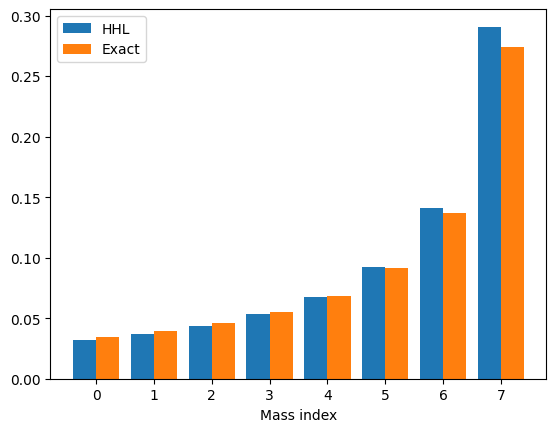

In [7]:
import matplotlib.pyplot as plt

bar_width = 0.4
plt.bar(np.arange(N) - bar_width/2, np.diff(x_HHL_normalized, prepend=0),
width=bar_width, label='HHL')
plt.bar(np.arange(N) + bar_width/2, np.diff(x_exact_normalized, prepend=0),
width=bar_width, label='Exact')
plt.xlabel('Mass index')
plt.legend()
plt.show()